In [1]:

# Other imports
%matplotlib inline
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import numpy as np
import sionna
no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies
from sionna.rt.utils import r_hat, subcarrier_frequencies

In [2]:
from sionna.rt import LambertianPattern, DirectivePattern, BackscatteringPattern,\
                      load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver, cpx_abs, cpx_convert




from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, watt_to_dbm,\
                      RadioMapSolver, PathSolver

In [3]:
scene = load_scene(sionna.rt.scene.munich) # Try also sionna.rt.scene.etoile

scene.frequency = 3.5e9 # in Hz; implicitly updates RadioMaterials

scene.synthetic_array = False # If set to False, ray tracing will be done per antenna element (slower for large arrays)

In [4]:
scene.remove("tx")
scene.remove("rx")
scene.remove("tx1")
# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=2.0,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             vertical_spacing=2.0,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="cross")

# Create transmitter


tx = Transmitter(name="tx",
                 position=[100,120,30])
# Create a receiver
scene.add(tx)

rx = Receiver(name="rx",
                 position=[50,50,30])

# Add transmitter instance to scene
scene.add(rx)

tx.look_at(rx) # Transmitter points towards receiver
 # Transmitter points towards receiver

In [5]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

In [6]:

scene.preview(paths=paths, clip_at=20)

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

In [7]:
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

# Add a transmitter and a receiver
scene.remove("tx")
scene.remove("rx")
scene.add(Transmitter("tx", [-25,0.1,50]))
scene.add(Receiver("rx",    [ 25,0.1,50]))

# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene, max_depth=1)

# Visualize the scene and propagation paths
scene.preview(paths=paths)

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, matrixWorldNeedsUpda…

In [8]:
print("Path interaction (0=LoS, 1=Specular reflection): ", paths.interactions.numpy())
print("Doppler shifts (Hz): ", paths.doppler.numpy())

Path interaction (0=LoS, 1=Specular reflection):  [[[[0 1 1]]]]
Doppler shifts (Hz):  [[[0. 0. 0.]]]


In [9]:
num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

# Add a transmitter and a receiver
scene.remove("tx")
scene.add(Transmitter("tx", [-25,0.1,50]))

scene.remove("jamming")
# scene.add(Transmitter("jamming", [8.5,21,27]))
scene.remove("rx")
scene.add(Receiver("rx",    [ 25,0.1,50]))


Delay   resolution (ns):  32
Doppler resolution (Hz):  29


In [13]:
# ===============================================
# ▶ 修改 －  直接分離 h_main 與 h_jam
# ===============================================
# frequencies 與 resource_grid 同原 notebook
p_solver = PathSolver()
paths = p_solver(scene=scene,
                 max_depth=8,
                 refraction=False)
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h = paths.cfr(frequencies=frequencies,
              sampling_frequency=1/ofdm_symbol_duration,
              num_time_steps=num_ofdm_symbols,
              normalize_delays=False, normalize=True, out_type="numpy")

# 將兩者 reshape 成 [num_slots, num_ut, num_rx_ant, num_tx_ant, sym, subc]
h_main = tf.expand_dims(h_main, 1)
h_jam  = tf.expand_dims(h_jam,  1)

h_main = tf.reshape(h_main, [num_slots, num_ut] + h_main.shape[2:])
h_jam  = tf.reshape(h_jam,  [num_slots, num_ut] + h_jam.shape[2:])


NameError: name 'tf' is not defined

In [14]:



# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

# Visualize the scene and propagation paths
scene.preview(paths=paths)
num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))

# Set TX velocity
tx_velocity = [30, 0, 0]
scene.get("tx").velocity = tx_velocity

# Recompute the paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h = paths.cfr(frequencies=frequencies,
              sampling_frequency=1/ofdm_symbol_duration,
              num_time_steps=num_ofdm_symbols,
              normalize_delays=False, normalize=True, out_type="numpy")

print("h shape",h.shape)
### Compute the Delay-Doppler spectrum

# Squeeze useless dimensions
# [num_time_steps, fft_size]
h = np.squeeze(h)

print("h_squeeze shape",h.shape)

h = h[3 ,3 ,: ,:]
# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h = np.fft.fftshift(h, axes=1)

print("h np.fft.fftshift(h, axes=1) shape",h.shape)
# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

print("h_delay np.fft.ifft(h, axis=1, norm=ortho) shape",h_delay.shape)
# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

print("h_delay_doppler = np.fft.fft(h_delay, axis=0, norm=ortho shape",h_delay_doppler.shape)

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

print("h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0) shape",h_delay_doppler.shape)

# Compute meshgrid for visualization of the Delay-Doppler spectrum
doppler_bins = np.arange(-num_ofdm_symbols/2*doppler_resolution,
                          num_ofdm_symbols/2*doppler_resolution,
                         doppler_resolution)

delay_bins = np.arange(0,
                       num_subcarriers*delay_resolution,
                       delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

# Visualize Delay-Doppler spectrum
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# We only visualize the relevant part of the spectrum
offset = 20
x_start = int(num_subcarriers/2)-offset
x_end = int(num_subcarriers/2)+offset
y_start = 0
y_end = offset
x_grid = x[x_start:x_end,y_start:y_end]
y_grid = y[x_start:x_end,y_start:y_end]
z_grid = np.abs(h_delay_doppler[x_start:x_end,y_start:y_end])

surf = ax.plot_surface(x_grid,
                       y_grid,
                       z_grid,
                       cmap='viridis', edgecolor='none')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler (Hz)')
ax.set_zlabel('Magnitude');
ax.zaxis.labelpad=2
ax.view_init(elev=53, azim=-32)
ax.set_title("Delay-Doppler Spectrum");

Delay   resolution (ns):  32
Doppler resolution (Hz):  29
h shape (1, 1, 1, 1, 1024, 1024)
h_squeeze shape (1024, 1024)


IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

In [ ]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=5,
               samples_per_tx=10**7,
               cell_size=(5, 5),
               center=[0, 0, 0],
               size=[400, 400],
               orientation=[0, 0, 0])

rm.show(metric="sinr", tx=None, vmin=0, vmax=70);
# Show maximum SINR across all transmitters
rm.show(metric="sinr", tx=0, vmin=0, vmax=70);
rm.show(metric="sinr", tx=1, vmin=0, vmax=70);


Delay   resolution (ns):  32
Doppler resolution (Hz):  29
h shape (1, 1, 2, 1, 1024, 1024)
h_squeeze shape (2, 1024, 1024)
h np.fft.fftshift(h, axes=1) shape (1024, 1024)
h_delay np.fft.ifft(h, axis=1, norm=ortho) shape (1024, 1024)
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm=ortho shape (1024, 1024)
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0) shape (1024, 1024)


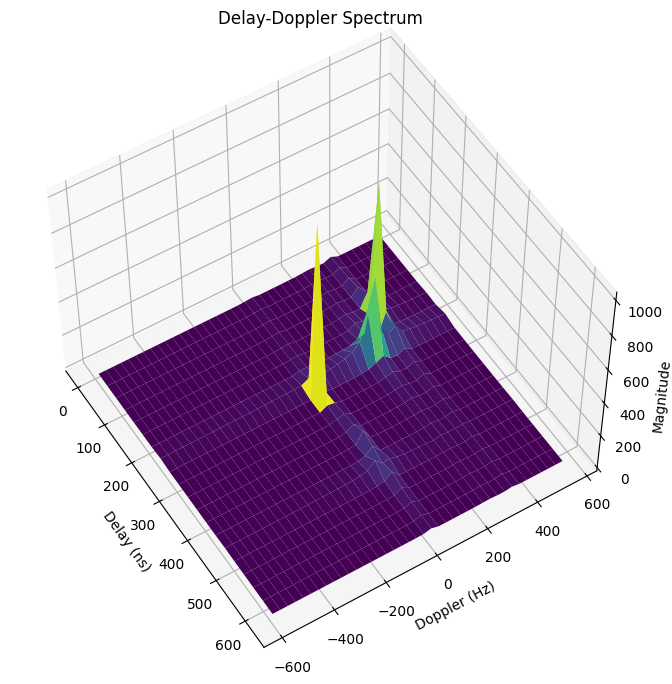

In [10]:
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

# Add a transmitter and a receiver
scene.remove("tx")
scene.add(Transmitter("tx", [-25,0.1,50]))

scene.remove("jamming")
scene.add(Transmitter("jamming", [100,21,50]))
scene.remove("rx")
scene.add(Receiver("rx",    [ 25,0.1,50]))


# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

# Visualize the scene and propagation paths
scene.preview(paths=paths)
num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))

# Set TX velocity
tx_velocity = [30, 0, 0]
scene.get("tx").velocity = tx_velocity

# Recompute the paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h = paths.cfr(frequencies=frequencies,
              sampling_frequency=1/ofdm_symbol_duration,
              num_time_steps=num_ofdm_symbols,
              normalize_delays=False, normalize=True, out_type="numpy")


print("h shape",h.shape)
### Compute the Delay-Doppler spectrum

# Squeeze useless dimensions
# [num_time_steps, fft_size]
h = np.squeeze(h)

print("h_squeeze shape",h.shape)
h_sum = h[:, :, :]     # shape (2,1024,1024)
h = np.sum(h, axis=0)  # shape (1024,1024)


# h = h[3 ,3 ,: ,:]
# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h = np.fft.fftshift(h, axes=1)

print("h np.fft.fftshift(h, axes=1) shape",h.shape)
# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

print("h_delay np.fft.ifft(h, axis=1, norm=ortho) shape",h_delay.shape)
# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

print("h_delay_doppler = np.fft.fft(h_delay, axis=0, norm=ortho shape",h_delay_doppler.shape)

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

print("h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0) shape",h_delay_doppler.shape)

# Compute meshgrid for visualization of the Delay-Doppler spectrum
doppler_bins = np.arange(-num_ofdm_symbols/2*doppler_resolution,
                          num_ofdm_symbols/2*doppler_resolution,
                         doppler_resolution)

delay_bins = np.arange(0,
                       num_subcarriers*delay_resolution,
                       delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

# Visualize Delay-Doppler spectrum
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# We only visualize the relevant part of the spectrum
offset = 20
x_start = int(num_subcarriers/2)-offset
x_end = int(num_subcarriers/2)+offset
y_start = 0
y_end = offset
x_grid = x[x_start:x_end,y_start:y_end]
y_grid = y[x_start:x_end,y_start:y_end]
z_grid = np.abs(h_delay_doppler[x_start:x_end,y_start:y_end])

surf = ax.plot_surface(x_grid,
                       y_grid,
                       z_grid,
                       cmap='viridis', edgecolor='none')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler (Hz)')
ax.set_zlabel('Magnitude');
ax.zaxis.labelpad=2
ax.view_init(elev=53, azim=-32)
ax.set_title("Delay-Doppler Spectrum");

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 僅用於 3D 投影


print(h_sum.shape)
# 假設 h_sum 已在前面計算得到，形狀為 (1024, 1024)
# 我們這裡構造一個網格，直接用矩陣索引作為 X, Y 軸
h = np.sum(h_sum, axis=0)  # shape (1024,1024)
nx, ny = h.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

# 對 h_sum 求幅值，因為 h_sum 可能是複數
Z = np.abs(h)

# 建立 3D 圖
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 使用 plot_surface 畫出 3D 曲面
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
surf.set_clim(vmin=0, vmax=1.4)

# 添加顏色條，便於觀察幅值的大小
fig.colorbar(surf, shrink=0.5, aspect=5)

# 設置標籤和標題
ax.set_title("3D Surface Plot of h_0")
ax.set_xlabel("Index X")
ax.set_ylabel("Index Y")
ax.set_zlabel("Magnitude")

plt.show()


In [ ]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1,1],
               samples_per_tx=10**6)

In [ ]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cir(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:])
plt.xlabel("Subcarrier index")
plt.ylabel(r"|$h_\text{freq}$|")
plt.title("Channel frequency response")

In [ ]:
scene.preview()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def angle_delay_transform(h_freq):
    """
    - 先對 subcarriers (頻域) 做 IFFT -> 時延域 (Delay)
    - 再對 rx_antenna (空域) 做 FFT -> 角度域 (AOA)
    """
    # Step 1: IFFT over subcarriers (Convert to Delay domain)
    h_delay = np.fft.ifft(h_freq, axis=-1)

    # Step 2: FFT over rx_antenna (Convert to Angle domain)
    h_angle_delay = np.fft.fftshift(np.fft.fft(h_delay, axis=0), axes=0)

    return h_angle_delay


# **1. 取得「無干擾」場景的 CSI**
h_tx1_no_jamming = h_freq.numpy()[0, 0, :, 0, 0, 0, :]  # Tx1 in No Jamming scenario

# **2. 取得「有干擾」場景的 CSI**
h_tx1_jamming = h_freq.numpy()[0, 0, :, 0, 0, 0, :]  # Tx1 in Jamming scenario
h_tx2_jamming = h_freq.numpy()[0, 0, :, 1, 0, 0, :]  # Tx2 (Jammer) in Jamming scenario

# **3. 計算合併通道 (有干擾場景的 Rx 端接收通道)**
h_combined = h_tx1_jamming + h_tx2_jamming  # Rx 端實際接收的總信號

# **4. 進行 Angle-Delay 轉換**
H_no_jam_ad = angle_delay_transform(h_tx1_no_jamming)  # 無干擾 Tx1
H_jam_ad = angle_delay_transform(h_combined)           # 有干擾 (Tx1 + Tx2)

# 計算 dB 值
mag_no_jam = 20 * np.log10(np.abs(H_no_jam_ad) + 1e-9)
mag_jam = 20 * np.log10(np.abs(H_jam_ad) + 1e-9)

# 設定全局的色階範圍
vmin = min(mag_no_jam.min(), mag_jam.min())
vmax = max(mag_no_jam.max(), mag_jam.max())

plt.figure(figsize=(12,5))

# 無干擾場景
plt.subplot(1,2,1)
plt.imshow(mag_no_jam, aspect='auto', cmap='jet', vmin=vmin, vmax=vmax)
plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Delay Index")
plt.ylabel("Angle Index")
plt.title("AOA vs. Delay (No Jamming)")

# 有干擾場景
plt.subplot(1,2,2)
plt.imshow(mag_jam, aspect='auto', cmap='jet', vmin=vmin, vmax=vmax)
plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Delay Index")
plt.ylabel("Angle Index")
plt.title("AOA vs. Delay (Jamming)")

plt.tight_layout()
plt.show()


In [ ]:
import mitsuba as mi
import drjit as dr
import numpy as np
import matplotlib.pyplot as plt
import sionna.rt
from sionna.rt import Transmitter, Receiver, PathSolver

# ----------------------------
# 1. 建立場景與加入 Tx 與多個 Rx
# ----------------------------
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array
# 移除現有的 Tx（如果有）
scene.remove("tx")
# 加入一個 Tx
scene.add(Transmitter(name="tx", position=[8.5, 21, 27]))

# 建立 XY 平面網格（固定高度 1.5）
x_range = np.linspace(30, 60, 50)
y_range = np.linspace(80, 100, 50)
# 產生所有接收器位置，每個位置格式為 [x, y, 1.5]
rx_positions = [[np.float32(x), np.float32(y), np.float32(1.5)]
                for x in x_range for y in y_range]

# 加入多個 Receiver
for i, pos in enumerate(rx_positions):
    # 若直接傳入 pos 會有型別問題，這裡轉換為 tuple 再建立 Point3f
    pos_tuple = (float(pos[0]), float(pos[1]), float(pos[2]))
    scene.add(Receiver(name=f"rx_{i}", position=mi.Point3f(*pos_tuple)))

In [ ]:
import mitsuba as mi
import drjit as dr
import numpy as np
import matplotlib.pyplot as plt
import sionna.rt
from sionna.rt import Transmitter, Receiver, PathSolver

# ----------------------------
# 1. 建立場景與加入 Tx 與多個 Rx
# ----------------------------
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array
# 移除現有的 Tx（如果有）
scene.remove("tx")
# 加入一個 Tx
scene.add(Transmitter(name="tx", position=[8.5, 21, 27]))

# 建立 XY 平面網格（固定高度 1.5）
x_range = np.linspace(30, 60, 50)
y_range = np.linspace(80, 100, 50)
# 產生所有接收器位置，每個位置格式為 [x, y, 1.5]
rx_positions = [[np.float32(x), np.float32(y), np.float32(1.5)]
                for x in x_range for y in y_range]

# 加入多個 Receiver
for i, pos in enumerate(rx_positions):
    # 若直接傳入 pos 會有型別問題，這裡轉換為 tuple 再建立 Point3f
    pos_tuple = (float(pos[0]), float(pos[1]), float(pos[2]))
    scene.add(Receiver(name=f"rx_{i}", position=mi.Point3f(*pos_tuple)))
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

# ----------------------------
# 2. 計算傳播路徑
# ----------------------------
solver = PathSolver()
# 使用 synthetic_array=True：此時每個接收器視為一個點
paths = solver(scene=scene, max_depth=3, synthetic_array=True)

# ----------------------------
# 3. 提取每個接收器的 AoA（這裡取第一條路徑的 azimuth 角 phi_r）
# ----------------------------
# 假設 paths.phi_r 的 shape 為 [num_tx, num_rx, 1, 1, num_paths]
# 我們取第0個 Tx、每個 Rx 的第一條路徑
phi_r_values = []
num_rx = len(rx_positions)
for i in range(num_rx):
    # 由於 shape 為 (2500, 1, 8)，使用索引 [i, 0, 0] 取得第 i 個接收器第一條路徑的 AoA
    phi_r = paths.phi_r.numpy()[i, 0, 0]
    phi_r_deg = np.degrees(phi_r)
    phi_r_values.append(phi_r_deg)

# ----------------------------
# 4. 繪製 AoA map
# ----------------------------
x_coords = np.array([float(pos[0]) for pos in rx_positions])
y_coords = np.array([float(pos[1]) for pos in rx_positions])

plt.figure(figsize=(8, 6))
sc = plt.scatter(x_coords, y_coords, c=phi_r_values, cmap='viridis', s=20)
plt.colorbar(sc, label='AoA (degrees)')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('AoA Map (Synthetic Array)')
plt.show()


In [ ]:
print(paths.phi_r.shape)

In [ ]:
theta_r_values = []
for i in range(num_rx):
    theta_r = paths.theta_r.numpy()[i, 0, 2]  # 注意這是 elevation angle
    theta_r_deg = np.degrees(theta_r)
    theta_r_values.append(theta_r_deg)
Z = np.array(theta_r_values).reshape(len(y_range), len(x_range))  # shape (50, 50)
X, Y = np.meshgrid(x_range, y_range)

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=100, cmap='viridis')  # 平滑填色
plt.colorbar(contour, label='AOA θ (degrees)')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('AOA_theta Map (Elevation)')
plt.show()
